#  **1D U-Net for gaussian denoising in NMR signals**

This notebook contains the complete computational pipeline for the model introduced in the paper titled: *Robust U-Net Reconstruction of NMR Signals and Spectra in Noisy and Inhomogeneous Magnetic Fields*

Authors: Alfredo Aguilar, Lautaro Piermartini, and Esteban Anoardo.

Laboratorio de Relaxometría y Técnicas Especiales (LaRTE) - UNC-FaMAF - 2026.
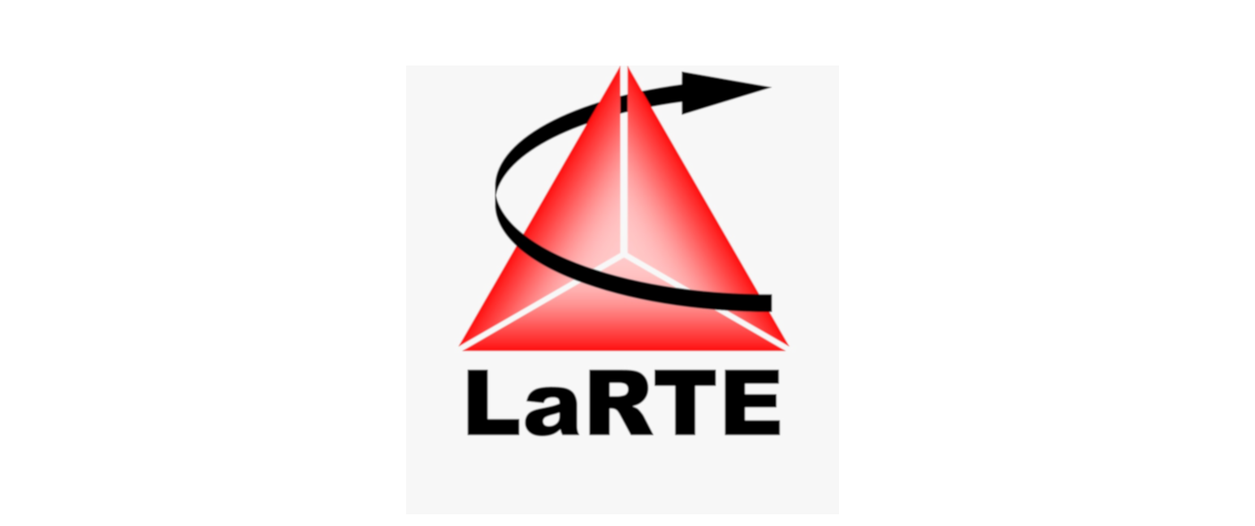

In [ ]:
!pip -q install tensorflow

In [ ]:
# best trained on GPU or TPU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob
import os, json
import pickle
import joblib

import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

from google.colab import files
from zipfile import ZipFile

os.makedirs('resultados', exist_ok=True) # folder to save all outputs


In [ ]:
# upload modules

print("Upload the module: u_net.py")

uploaded = files.upload()

from u_net import build_unet_1d, add_gaussian_noise


In [ ]:
# general parameters

#-------------------------------------------------------------------------------------------------------------------#
#-------------------------------------------------------------------------------------------------------------------#
epocas = 150         # general parameters. max epochs
batch_size = 128     # batch size (smaller improves precision but requires higher lr)
metric_loss = 'mse'  # loss metric
q_norm = 0.995       # normalization quantile (99.5%) instead of dividing by max
eps = 1e-12          # prevents zero division where needed

early_stop_patience = 30     # epochs for early stopping
early_stop_min_delta = 1e-4  # stops training if improvement is < min_delta

reduce_lr_factor = 0.7       # learning rate reduction factor
reduce_lr_patience = 7       # epochs to wait before reducing lr
reduce_lr_min_delta = 1e-3   # reduces lr if improvement is < min_delta
lr = 5e-6                    # initial learning rate
lr_min = 5e-8                # min learning rate

n_plot = 10          # random plots for validation and test
dpi = 300            # image saving resolution
IQR_factor = 1.5     # outlier detection factor for preprocessing

#-------------------------------------------------------------------------------------------------------------------#
#-------------------------------------------------------------------------------------------------------------------#
filtros_base = 32    # main u-net hyperparameters
filtros_depth = 3    # use 4 for finer details (tends to overfit slightly) - No improvements are visible.
kernel = 7           # kernel size
drop_out = 0.03      # dropout rate


#-------------------------------------------------------------------------------------------------------------------#
#-------------------------------------------------------------------------------------------------------------------#
n_synthetic = 3000      # added gaussian noise parameters. noisy spectra in train and val per targets_snr_db
n_synthetic_test = 1500 # spectra for test evaluation
random_state = 0

targets_snr_db = [35, 30, 25, 20, 18, 16, 14, 12, 10, 8, 6, 4, 2, 1] # snr in db (higher values mean less added gaussian noise)


In [ ]:
# upload required files

print("upload files: FIDs.zip and times.csv")  # Or FFTs.zip for spectra
uploaded = files.upload()

# extract zip with signals
for fname in uploaded.keys():
    if fname.endswith('.zip'):
        with ZipFile(fname, 'r') as zip_ref:
            zip_ref.extractall()
        print(f"extracted: {fname}")

In [ ]:
# define paths, cropping range and signal split for train/test

ruta_fids = './FIDs'  # signals are in this folder
ruta_times = './times.csv'

#-------------------------------------------------------------------------------------------------------------------#
# t range
t_min = float(input("Enter minimum time value in [s]: "))
t_max = float(input("Enter maximum time value in [s]: "))

print(f"selected time range: {t_min} s,  {t_max} s")
print(f"files ready to process in: {ruta_fids}")

#-----------------------------------------------------------------------------------------------------------------------------#
# number of signals for train + test (in experimental order)
num_train_test = int(input("Enter signal number to split train + test from. starting from 1:  "))

In [ ]:
# signal cropping

#-----------------------------------------------------------------------------------------------------------------------------#
ruta_fids = './FFTs' if os.path.exists('./FFTs') else './FIDs'  # auto-detect input folder depending on the available data
#-----------------------------------------------------------------------------------------------------------------------------#

if ruta_fids == './FFTs':
    archivos_temp = glob.glob(os.path.join(ruta_fids, '*.csv'))
    times = pd.read_csv(archivos_temp[0], header=None, sep=r'\s+').iloc[:, 0].values  # extract the frequency axis from the first CSV
else:
    times = pd.read_csv('./times.csv', header=None).iloc[:, 0].values  # otherwise, load the global time axis from the master file

with open('rango_t.pkl', 'wb') as f:
    pickle.dump({'t_min': t_min, 't_max': t_max}, f)  # save the cropping bounds for future reference or inference

idx_rec = np.flatnonzero((times >= t_min) & (times <= t_max))  # find indices falling within the defined limits (time or frequency)
if idx_rec.size == 0:
    raise ValueError(f"No se encontraron puntos en el rango {t_min}-{t_max}.")

p = idx_rec.size  # total number of data points retained after cropping
print(f"Recorte: {t_min}–{t_max} -> {p} puntos; índices {idx_rec[0]}..{idx_rec[-1]}")

csv_files = sorted( glob.glob(os.path.join(ruta_fids, '*.csv')),
    key=lambda x: int(''.join(filter(str.isdigit, os.path.basename(x))))  )  # sort files numerically by extracting digits to prevent OS-level misordering

#-----------------------------------------------------------------------------------------------------------------------------#
# randomly shuffle signals
rng = np.random.default_rng(random_state)
rng.shuffle(csv_files)

#------------------------------------------------------------------------------------------------#
# process and extract only the band of interest
fids = []
for i, fpath in enumerate(tqdm(csv_files, desc="processing fids", ncols=100, leave=False)):
    fid_df = pd.read_csv(fpath, header=None, sep=r'\s+')
    amp = fid_df.iloc[:,1].values
    if amp.shape[0] != times.shape[0]:
        raise ValueError(f"amplitude length in {fpath} ({amp.shape[0]}) != times ({times.shape[0]}).")
    fids.append(amp[idx_rec])   # use the unique index

#------------------------------------------------------------------------------------------------#
# create X matrix and y labels
X = np.array(fids, dtype=float)   # shape: (M, p)
print(f"X dimension: {X.shape}")


# define time vector for plotting
t_axis = times[idx_rec]
assert X.shape[1] == len(t_axis), "mismatch between X columns and t_axis"

In [ ]:
# verify crop

# show a random signal
idx = np.random.randint(0, len(X))

plt.figure(figsize=(8,4))
plt.plot(t_axis, X[idx, :], label=f'signal {idx + 1}')
plt.xlabel('t [s]')
plt.ylabel('amplitude (a.u.)')
plt.title(f'cropped fid {idx + 1} ({t_min}–{t_max} s)')
plt.legend()
plt.show()

In [ ]:
# filter nans
# for 2d X (n_signals, n_points)

print("original data count:", X.shape[0])

#------------------------------------------------------------------------------------------------#
mask_nan = ~np.isnan(X).any(axis=1)
X = X[mask_nan]
print(f"after removing nans: {X.shape[0]} samples (discarded {np.sum(~mask_nan)})")
#------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------#
# verify final dimensions
print("X dimension: ", X.shape)

In [ ]:
# train split

#------------------------------------------------------------------------------------------------#
# manual data split
X_train, X_test = X[:num_train_test], X[num_train_test:]

# X scaling:
#------------------------------------------------------------------------------------------------#
scaler_x = StandardScaler()

# X_train and X_test are 2d (N, p)
X_train_2d = X_train
X_test_2d  = X_test

# X scaling (consistent with max normalization at a high quantile)
X_train_norm = X_train_2d / np.maximum(np.quantile(X_train_2d, q_norm, axis=1, keepdims=True), eps)
X_test_norm  = X_test_2d  / np.maximum(np.quantile(X_test_2d,  q_norm, axis=1, keepdims=True), eps)

scaler_x.fit(X_train_norm)
X_train = scaler_x.transform(X_train_norm)
X_test  = scaler_x.transform(X_test_norm)

# add channel dimension + dtype
X_train = X_train[..., np.newaxis].astype(np.float32)
X_test  = X_test[..., np.newaxis].astype(np.float32)


# tensor dimensions
#------------------------------------------------------------------------------------------------#
print("X_train shape ", X_train.shape)
print("X_test shape ", X_test.shape)

#------------------------------------------------------------------------------------------------#
p = X_train.shape[1]    # points per signal
print('points per signal:', p)

In [ ]:
# build and compile the model:

model = build_unet_1d(input_length= p, n_channels= 1, base_filters= filtros_base, depth= filtros_depth,
            kernel_size= kernel, dropout= drop_out)

model.compile(optimizer=Adam(learning_rate= lr), loss= metric_loss)


#------------------------------------------------------------------------------------------------#
model.summary()

In [ ]:
# training/augmentation parameters

#------------------------------------------------------------------------------------------------#
print('using real scale signals (train), normalized, and adding direct gaussian noise...')

# X_train_2d is in raw scale and cropped to p points
X_syn_raw = X_train_2d / np.maximum(np.quantile(X_train_2d, q_norm, axis=1, keepdims=True), eps) # high quantile normalization. (N_train, p)


# sample real signals with replacement. just repeats signals (and then changes noise realization).
if n_synthetic is not None and n_synthetic != X_syn_raw.shape[0]:
    rng = np.random.default_rng(random_state)
    replace = n_synthetic > X_syn_raw.shape[0]
    idx = rng.choice(X_syn_raw.shape[0], size=n_synthetic, replace=replace)
    X_syn_raw = X_syn_raw[idx]

print('X_syn_raw shape (train norm):', X_syn_raw.shape)


#------------------------------------------------------------------------------------------------#
# generate noise levels
std_global = np.median(X_syn_raw.std(axis=1))   # X_syn_raw is normalized
sigma_list = [std_global / (10**(snr/20)) for snr in targets_snr_db]

In [ ]:
# build dataset with different noise levels (all in raw scale and then scaled)

pairs_noisy_raw = []
pairs_clean_raw = []

for sig in sigma_list:  # add gaussian noise
    noisy_raw = add_gaussian_noise(X_syn_raw, sig)
    pairs_noisy_raw.append(noisy_raw)
    pairs_clean_raw.append(X_syn_raw.copy())

X_noisy_raw = np.vstack(pairs_noisy_raw)   # (n_synthetic * n_sigma, p)
X_clean_raw = np.vstack(pairs_clean_raw)

print('shape X_noisy_raw, X_clean_raw:', X_noisy_raw.shape, X_clean_raw.shape)
print('raw min/max (clean):', X_clean_raw.min(), X_clean_raw.max())
print('raw min/max (noisy):', X_noisy_raw.min(), X_noisy_raw.max())

#------------------------------------------------------------------------------------------------#
# scale
X_noisy = scaler_x.transform(X_noisy_raw)
X_clean = scaler_x.transform(X_clean_raw)

# shuffle & split, reshape to (N, p, 1)
perm = np.random.default_rng(0).permutation(X_noisy.shape[0])
X_noisy = X_noisy[perm]; X_clean = X_clean[perm]
n_train = int(0.8 * X_noisy.shape[0])

Xn_train, Xn_val = X_noisy[:n_train], X_noisy[n_train:]
Xc_train, Xc_val = X_clean[:n_train], X_clean[n_train:]

Xn_train = Xn_train[..., np.newaxis].astype(np.float32)
Xn_val   = Xn_val[..., np.newaxis].astype(np.float32)
Xc_train = Xc_train[..., np.newaxis].astype(np.float32)
Xc_val   = Xc_val[..., np.newaxis].astype(np.float32)


#------------------------------------------------------------------------------------------------#
print('shapes after scaling and reshape:', Xn_train.shape, Xc_train.shape)

**TRAINING**

In [ ]:
mc = ModelCheckpoint('resultados/best_weights.weights.h5', monitor='val_loss', save_best_only=True,
         save_weights_only=True, mode='min')

# callbacks
#--------------------------------------------------------------------------------------------------------------------------------#
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor= reduce_lr_factor, patience= reduce_lr_patience, min_delta= reduce_lr_min_delta,
        min_lr= lr_min, verbose=1),
    EarlyStopping(monitor='val_loss', patience= early_stop_patience, min_delta= early_stop_min_delta,
        restore_best_weights=True, verbose=1), mc ]


#--------------------------------------------------------------------------------------------------------------------------------#
# training
history = model.fit(Xn_train, Xc_train, validation_data=(Xn_val, Xc_val), batch_size=batch_size,
                    epochs=epocas, callbacks=callbacks, shuffle=True)


#--------------------------------------------------------------------------------------------------------------------------------#
df_hist = pd.DataFrame(history.history)

output_file = os.path.join('resultados', 'training.csv')
df_hist.to_csv(output_file, index=False)

In [ ]:
# training loss vs validation loss

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

#------------------------------------------------------------------------------------------------#
# plot
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, 'b-', label='loss')
plt.plot(epochs, val_loss, 'r-', label='val loss')
plt.ylim(min(loss),max(val_loss))
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.savefig("resultados/val_loss_vs_loss.png", dpi= dpi)
plt.show()

In [ ]:
# predictions (scaled)

preds = model.predict(Xn_val)   # preds will have shape (N, p, 1)

# preds, Xn_val, Xc_val have shape (N, p, 1)
preds_2d = preds[..., 0]      # (N, p)
noisy_2d = Xn_val[..., 0]
clean_2d = Xc_val[..., 0]


#------------------------------------------------------------------------------------------------#
# inverse transform the standardscaler
preds_real = scaler_x.inverse_transform(preds_2d)
noisy_real = scaler_x.inverse_transform(noisy_2d)
clean_real = scaler_x.inverse_transform(clean_2d)

In [ ]:
# psnr/ssim metrics on validation (from noisy synthetic signals)

psnr_vals = []
ssim_vals = []
for i in range(len(clean_real)):
    ref = clean_real[i]
    den = preds_real[i]
    # data_range: use dynamic range of the reference
    dr = ref.max() - ref.min()
    if dr <= 0:
        dr = 1.0
    psnr_vals.append(psnr(ref, den, data_range=dr))
    # ssim may require float arrays; works for 1d even though it is designed for images
    ssim_vals.append(ssim(ref, den, data_range=dr))


#------------------------------------------------------------------------------------------------#
print('psnr median  (db):', np.median(psnr_vals), 'mean:', np.mean(psnr_vals))
print('ssim median  (<1):', np.median(ssim_vals), 'mean:', np.mean(ssim_vals))

In [ ]:
#----------------------------------------------------------#
#   graphic examples (in validation) in real scale


nplot = n_plot   # plot n_plot random examples
idxs = np.random.choice(clean_real.shape[0], nplot, replace=False)

#------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(nplot, 1, figsize=(8, 3*nplot))
for j, i in enumerate(idxs):

    axs[j].scatter(t_axis, noisy_real[i, :], label='noisy', alpha=0.7, color='blue', s=1.2)
    axs[j].plot(t_axis, noisy_real[i, :], alpha=0.6, linewidth=0.7, color='blue')
    axs[j].plot(t_axis, preds_real[i, :], label='denoised', linewidth=0.9, color='green')
    axs[j].plot(t_axis, clean_real[i, :], label='reference', linewidth=0.9, color='black')
    axs[j].legend()
    axs[j].set_xlabel('t [s]')
    axs[j].set_ylabel('amplitude (a.u.)')

plt.tight_layout()
plt.savefig('resultados/u_net_val.png', dpi= dpi)
plt.show()

In [ ]:
# psnr/ssim metrics on test (synthetic signals with added noise)

print(X_test_2d.shape)


# signals (test) in normalized scale (by a high quantile)
X_syn_test_raw = X_test_2d / np.maximum(np.quantile(X_test_2d, q_norm, axis=1, keepdims=True), eps)  # shape: (N_test, p)

# sampling with/without replacement
if n_synthetic_test is not None and n_synthetic_test != X_syn_test_raw.shape[0]:
    rng = np.random.default_rng(123)
    replace = n_synthetic_test > X_syn_test_raw.shape[0]
    idx = rng.choice(X_syn_test_raw.shape[0], size=n_synthetic_test, replace=replace)
    X_syn_test_raw = X_syn_test_raw[idx]


#------------------------------------------------------------------------------------------------#
# build pairs (noisy, clean) in raw scale for the same snrs as in train
pairs_noisy_test_raw = []
pairs_clean_test_raw = []

for sig in sigma_list: # add gaussian noise
    noisy_raw = add_gaussian_noise(X_syn_test_raw, sig)
    pairs_noisy_test_raw.append(noisy_raw)
    pairs_clean_test_raw.append(X_syn_test_raw)

X_noisy_test_raw = np.vstack(pairs_noisy_test_raw)
X_clean_test_raw = np.vstack(pairs_clean_test_raw)

print('test raw shapes (noisy, clean):', X_noisy_test_raw.shape, X_clean_test_raw.shape)


#------------------------------------------------------------------------------------------------#
# 2d scaling
X_noisy_test = scaler_x.transform(X_noisy_test_raw)
X_clean_test = scaler_x.transform(X_clean_test_raw)

# add channel dimension again: (N, p) -> (N, p, 1)
Xn_test = X_noisy_test[..., np.newaxis].astype(np.float32)
Xc_test = X_clean_test[..., np.newaxis].astype(np.float32)

print('test shapes after scaling and reshape:', Xn_test.shape, Xc_test.shape)


#------------------------------------------------------------------------------------------------#
# predictions (scaled)
preds_test_scaled = model.predict(Xn_test, batch_size=batch_size)
preds_test_2d = preds_test_scaled[..., 0]
noisy_test_2d = Xn_test[..., 0]
clean_test_2d = Xc_test[..., 0]

# revert to real scale (original intensities)
preds_test_real = scaler_x.inverse_transform(preds_test_2d)
noisy_test_real = scaler_x.inverse_transform(noisy_test_2d)
clean_test_real = scaler_x.inverse_transform(clean_test_2d)


#----------------------------------------------------------#
#   psnr/ssim/rmse/snr metrics on test

psnr_vals_test = []
ssim_vals_test = []
rmse_vals_test = []

snr_in_vals_test = []
snr_out_vals_test = []
snr_gain_vals_test = []

for i in range(clean_test_real.shape[0]):

    ref = clean_test_real[i]
    noisy = noisy_test_real[i]
    den = preds_test_real[i]

    # data_range: use dynamic range of the reference
    dr = ref.max() - ref.min()
    if dr <= 0:
        dr = 1.0

    # psnr
    psnr_vals_test.append( psnr(ref, den, data_range=dr) )

    # ssim
    ssim_vals_test.append( ssim(ref, den, data_range=dr) )

    # rmse
    rmse = np.sqrt(np.mean((ref - den)**2))
    rmse_vals_test.append(rmse)

    #------------------------------------------------------#
    # input, output and gain snr

    signal_rms = np.sqrt(np.mean(ref**2))

    noise_in_rms = np.sqrt( np.mean((noisy - ref)**2) )

    noise_out_rms = np.sqrt( np.mean((den - ref)**2) )

    snr_in = 20*np.log10( signal_rms / np.maximum(noise_in_rms, eps) )

    snr_out = 20*np.log10( signal_rms / np.maximum(noise_out_rms, eps) )

    snr_gain = snr_out - snr_in

    snr_in_vals_test.append(snr_in)
    snr_out_vals_test.append(snr_out)
    snr_gain_vals_test.append(snr_gain)


#------------------------------------------------------------------------------------------------#
print('test - psnr median  (db):', np.median(psnr_vals_test),'mean:', np.mean(psnr_vals_test))

print('test - ssim median  (<1):', np.median(ssim_vals_test),'mean:', np.mean(ssim_vals_test))

print('test - rmse median:', np.median(rmse_vals_test),'mean:', np.mean(rmse_vals_test))

print('test - input snr median  (db):', np.median(snr_in_vals_test),'mean:', np.mean(snr_in_vals_test))

print('test - output snr median (db):', np.median(snr_out_vals_test),'mean:', np.mean(snr_out_vals_test))

print('test - snr gain median  (db):', np.median(snr_gain_vals_test),'mean:', np.mean(snr_gain_vals_test))

In [ ]:
#==========================================================#
#   NMR physical metrics on test for FIDs
#==========================================================#

from scipy.signal import find_peaks # check if this is used

#----------------------------------------------------------#
# auxiliary functions

def estimate_t2star(signal, t_axis, eps=1e-12):
    y = np.abs(signal)
    mask = y > np.max(y)*0.05

    if np.sum(mask) < 10:
        return np.nan

    t_fit = t_axis[mask]
    y_fit = y[mask]

    coeffs = np.polyfit( t_fit,  np.log(np.maximum(y_fit, eps)), 1  )

    slope = coeffs[0]

    if slope >= 0:
        return np.nan

    return -1.0/slope


def compute_fft_positive(signal, t_axis):

    dt = t_axis[1] - t_axis[0]

    fft_vals = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal), dt)

    mask = freqs >= 0

    return freqs[mask], fft_vals[mask]


def peak_frequency(freqs, spectrum):
    return freqs[np.argmax(spectrum)]


def fwhm(freqs, spectrum):

    idx_peak = np.argmax(spectrum)

    peak_amp = spectrum[idx_peak]

    half_max = peak_amp / 2.0

    left = idx_peak
    while left > 0 and spectrum[left] > half_max:
        left -= 1

    right = idx_peak
    while right < len(spectrum)-1 and spectrum[right] > half_max:
        right += 1

    if left == 0 or right == len(spectrum)-1:
        return np.nan

    return freqs[right] - freqs[left]


#----------------------------------------------------------#
# metrics

t2_clean_vals = []
t2_denoised_vals = []

peak_clean_vals = []
peak_denoised_vals = []

fwhm_clean_vals = []
fwhm_denoised_vals = []

# errors

t2_rel_error_vals = []

peak_abs_error_vals = []
peak_rel_error_vals = []

fwhm_abs_error_vals = []
fwhm_rel_error_vals = []

#----------------------------------------------------------#

for i in range(clean_test_real.shape[0]):

    clean = clean_test_real[i]
    den = preds_test_real[i]

    #------------------------------------------------------#
    # T2*

    t2_clean = estimate_t2star(clean, t_axis)
    t2_den = estimate_t2star(den, t_axis)

    t2_clean_vals.append(t2_clean)
    t2_denoised_vals.append(t2_den)

    if np.isfinite(t2_clean) and t2_clean > 0:
        t2_rel_error_vals.append( 100*np.abs(t2_den - t2_clean)/t2_clean )

    #------------------------------------------------------#
    # fft

    freqs_c, spec_c = compute_fft_positive(clean, t_axis)
    freqs_d, spec_d = compute_fft_positive(den, t_axis)

    peak_c = peak_frequency(freqs_c, spec_c)
    peak_d = peak_frequency(freqs_d, spec_d)

    peak_clean_vals.append(peak_c)
    peak_denoised_vals.append(peak_d)

    peak_abs_error_vals.append( np.abs(peak_d - peak_c) )

    if np.abs(peak_c) > eps:
        peak_rel_error_vals.append( 100*np.abs(peak_d - peak_c)/np.abs(peak_c) )

    #------------------------------------------------------#
    # fwhm

    fwhm_c = fwhm(freqs_c, spec_c)
    fwhm_d = fwhm(freqs_d, spec_d)

    fwhm_clean_vals.append(fwhm_c)
    fwhm_denoised_vals.append(fwhm_d)

    if np.isfinite(fwhm_c):

        fwhm_abs_error_vals.append( np.abs(fwhm_d - fwhm_c) )

        if fwhm_c > eps:

            fwhm_rel_error_vals.append( 100*np.abs(fwhm_d - fwhm_c)/fwhm_c )

#----------------------------------------------------------#
# results

print('\n==============================')
print('physical metrics on test')
print('==============================')

print('\nT2* relative error (%)')
print('median:', np.nanmedian(t2_rel_error_vals))
print('mean  :', np.nanmean(t2_rel_error_vals))

print('\npeak frequency error (hz)')
print('median:', np.nanmedian(peak_abs_error_vals))
print('mean  :', np.nanmean(peak_abs_error_vals))

print('\npeak frequency relative error (%)')
print('median:', np.nanmedian(peak_rel_error_vals))
print('mean  :', np.nanmean(peak_rel_error_vals))

print('\nfwhm error (hz)')
print('median:', np.nanmedian(fwhm_abs_error_vals))
print('mean  :', np.nanmean(fwhm_abs_error_vals))

print('\nfwhm relative error (%)')
print('median:', np.nanmedian(fwhm_rel_error_vals))
print('mean  :', np.nanmean(fwhm_rel_error_vals))

In [ ]:
#==========================================================#
#      NMR physical metrics on test for Spectra
#==========================================================#

from scipy.signal import find_peaks # check if this is used

#----------------------------------------------------------#
# auxiliary functions

def estimate_t2star(signal, t_axis, eps=1e-12):

    y = np.abs(signal)

    mask = y > np.max(y)*0.05

    if np.sum(mask) < 10:
        return np.nan

    t_fit = t_axis[mask]
    y_fit = y[mask]

    coeffs = np.polyfit( t_fit,  np.log(np.maximum(y_fit, eps)), 1  )

    slope = coeffs[0]

    if slope >= 0:
        return np.nan

    return -1.0/slope


def compute_fft_positive(signal, t_axis):

    dt = t_axis[1] - t_axis[0]

    fft_vals = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal), dt)

    mask = freqs >= 0

    return freqs[mask], fft_vals[mask]


def peak_frequency(freqs, spectrum):
    return freqs[np.argmax(spectrum)]


def fwhm(freqs, spectrum):

    idx_peak = np.argmax(spectrum)

    peak_amp = spectrum[idx_peak]

    half_max = peak_amp / 2.0

    left = idx_peak
    while left > 0 and spectrum[left] > half_max:
        left -= 1

    right = idx_peak
    while right < len(spectrum)-1 and spectrum[right] > half_max:
        right += 1

    if left == 0 or right == len(spectrum)-1:
        return np.nan

    return freqs[right] - freqs[left]

def main_peak_window(freqs, spectrum, half_fraction=0.5, window_factor=2.0, min_points=5, eps=1e-12):

    freqs = np.asarray(freqs)
    spectrum = np.asarray(spectrum)

    if len(freqs) != len(spectrum) or len(freqs) < min_points:
        return None

    # simple baseline correction to better define the peak
    baseline = np.percentile(spectrum, 5)
    spec = np.maximum(spectrum - baseline, 0.0)

    idx_peak = np.argmax(spec)
    peak_amp = spec[idx_peak]

    if peak_amp <= eps:
        return None

    half_max = half_fraction * peak_amp

    left = idx_peak
    while left > 0 and spec[left] > half_max:
        left -= 1

    right = idx_peak
    while right < len(spec)-1 and spec[right] > half_max:
        right += 1

    if left == 0 or right == len(spec)-1 or (right - left) < min_points:

        # fallback: low threshold window for the peak
        threshold = 0.05 * peak_amp

        left = idx_peak
        while left > 0 and spec[left] > threshold:
            left -= 1

        right = idx_peak
        while right < len(spec)-1 and spec[right] > threshold:
            right += 1

    if left == 0 or right == len(spec)-1 or (right - left) < min_points:
        return None

    f_peak = freqs[idx_peak]
    fwhm_local = freqs[right] - freqs[left]

    if not np.isfinite(fwhm_local) or fwhm_local <= 0:
        return None

    half_width = 0.5 * window_factor * fwhm_local

    f_min = f_peak - half_width
    f_max = f_peak + half_width

    mask = (freqs >= f_min) & (freqs <= f_max)

    if np.sum(mask) < min_points:
        return None

    return mask, f_min, f_max


def integrated_main_peak_power(freqs, spectrum, mask, baseline_percentile=5):

    freqs = np.asarray(freqs)
    spectrum = np.asarray(spectrum)

    baseline = np.percentile(spectrum, baseline_percentile)
    spec_bc = np.maximum(spectrum - baseline, 0.0)

    # local spectral power integral of the main peak
    return np.trapz(spec_bc[mask]**2, freqs[mask])

#----------------------------------------------------------#
# metrics

t2_clean_vals = []
t2_denoised_vals = []

peak_clean_vals = []
peak_denoised_vals = []

fwhm_clean_vals = []
fwhm_denoised_vals = []

peak_power_clean_vals = []
peak_power_denoised_vals = []

peak_power_abs_error_vals = []
peak_power_rel_error_vals = []

# errors

t2_rel_error_vals = []

peak_abs_error_vals = []
peak_rel_error_vals = []

fwhm_abs_error_vals = []
fwhm_rel_error_vals = []


#----------------------------------------------------------#

for i in range(clean_test_real.shape[0]):

    clean = clean_test_real[i]
    den = preds_test_real[i]

    #------------------------------------------------------#
    # T2*

    t2_clean = estimate_t2star(clean, t_axis)
    t2_den = estimate_t2star(den, t_axis)

    t2_clean_vals.append(t2_clean)
    t2_denoised_vals.append(t2_den)

    if np.isfinite(t2_clean) and t2_clean > 0:
        t2_rel_error_vals.append( 100*np.abs(t2_den - t2_clean)/t2_clean )

    #------------------------------------------------------#
    # fft

    freqs_c = t_axis
    spec_c = clean

    freqs_d = t_axis
    spec_d = den

    peak_c = peak_frequency(freqs_c, spec_c)
    peak_d = peak_frequency(freqs_d, spec_d)

    peak_clean_vals.append(peak_c)
    peak_denoised_vals.append(peak_d)

    peak_abs_error_vals.append( np.abs(peak_d - peak_c) )

    if np.abs(peak_c) > eps:
        peak_rel_error_vals.append( 100*np.abs(peak_d - peak_c)/np.abs(peak_c) )

    #------------------------------------------------------#
    # fwhm

    fwhm_c = fwhm(freqs_c, spec_c)
    fwhm_d = fwhm(freqs_d, spec_d)

    fwhm_clean_vals.append(fwhm_c)
    fwhm_denoised_vals.append(fwhm_d)

    if np.isfinite(fwhm_c):

        fwhm_abs_error_vals.append( np.abs(fwhm_d - fwhm_c) )

        if fwhm_c > eps:

            fwhm_rel_error_vals.append( 100*np.abs(fwhm_d - fwhm_c)/fwhm_c )


    #------------------------------------------------------#
    # integrated area/power of the main peak
    # important:
    # in this version, clean and den are already positive frequency spectra.
    # therefore t_axis is used as the frequency axis, keeping the current variable name.

    freqs_spec = t_axis
    spec_clean = clean
    spec_den = den

    peak_win = main_peak_window(freqs_spec, spec_clean)

    if peak_win is not None:

        peak_mask, f_left_peak, f_right_peak = peak_win

        peak_power_clean = integrated_main_peak_power(freqs_spec, spec_clean, peak_mask)
        peak_power_den = integrated_main_peak_power(freqs_spec, spec_den, peak_mask)

        peak_power_clean_vals.append(peak_power_clean)
        peak_power_denoised_vals.append(peak_power_den)

        peak_power_abs_error_vals.append( np.abs(peak_power_den - peak_power_clean) )

        if np.abs(peak_power_clean) > eps:
            peak_power_rel_error_vals.append(
                100*np.abs(peak_power_den - peak_power_clean)/np.abs(peak_power_clean)     )


#----------------------------------------------------------#
# results

print('\n==============================')
print('physical metrics on test')
print('==============================')

print('\nT2* relative error (%)')
print('median:', np.nanmedian(t2_rel_error_vals))
print('mean  :', np.nanmean(t2_rel_error_vals))

print('\npeak frequency error (hz)')
print('median:', np.nanmedian(peak_abs_error_vals))
print('mean  :', np.nanmean(peak_abs_error_vals))

print('\npeak frequency relative error (%)')
print('median:', np.nanmedian(peak_rel_error_vals))
print('mean  :', np.nanmean(peak_rel_error_vals))

print('\nfwhm error (hz)')
print('median:', np.nanmedian(fwhm_abs_error_vals))
print('mean  :', np.nanmean(fwhm_abs_error_vals))

print('\nfwhm relative error (%)')
print('median:', np.nanmedian(fwhm_rel_error_vals))
print('mean  :', np.nanmean(fwhm_rel_error_vals))

print('\nmain peak spectral power error')
print('median:', np.nanmedian(peak_power_abs_error_vals))
print('mean  :', np.nanmean(peak_power_abs_error_vals))

print('\nmain peak spectral power relative error (%)')
print('median:', np.nanmedian(peak_power_rel_error_vals))
print('mean  :', np.nanmean(peak_power_rel_error_vals))

In [ ]:
#----------------------------------------------------------#
#   graphic examples (on test) in normalized real scale

nplot = 100  # n_plot
n_disp = min(nplot, clean_test_real.shape[0])

idxs = np.random.default_rng(0).choice( clean_test_real.shape[0], n_disp,  replace=False)

#----------------------------------------------------------#
# save examples for paper figures

output_examples = os.path.join('resultados', 'ejemplos_test')

os.makedirs(output_examples, exist_ok=True)

for j, i in enumerate(idxs):

    df_example = pd.DataFrame({
        't': t_axis,
        'original': clean_test_real[i, :],
        'noisy': noisy_test_real[i, :],
        'denoised': preds_test_real[i, :]   })

    df_example.to_csv(
        os.path.join(
            output_examples,
            f'example_{j+1:02d}.csv' ), index=False )

#------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(n_disp, 1, figsize=(8, 3*n_disp), sharex=True)

if n_disp == 1:
    axs = [axs]

for j, i in enumerate(idxs):

    axs[j].scatter( t_axis, noisy_test_real[i, :], label='noisy', alpha=0.7, color='blue', s=4 )

    axs[j].plot(t_axis, noisy_test_real[i, :], alpha=0.6, linewidth=0.7, color='blue' )

    axs[j].plot(t_axis, preds_test_real[i, :], label='denoised', linewidth=0.9, color='green')

    axs[j].plot(t_axis, clean_test_real[i, :], label='original', linewidth=0.9, color='black' )

    axs[j].legend()
    axs[j].set_ylabel('amplitude (a.u.)')

axs[-1].set_xlabel('t [s]')

plt.tight_layout()
plt.savefig( 'resultados/u_net_TEST.png', dpi=dpi)

plt.show()

In [ ]:
model_path = os.path.join(f"resultados/Denoiser-Entrenado_{epocas}ep_{t_min}-{t_max}s.h5")  # save the model
model.save(model_path)

#------------------------------------------------------------------------------------------------#
joblib.dump(scaler_x, "resultados/scaler_x.pkl")  # save scalers


#------------------------------------------------------------------------------------------------#
meta = {  # save useful data for model loading (and reproducibility)
    "t_min": float(t_min),
    "t_max": float(t_max),
    "Puntos por señal": int(p),
    "Cantidad de señales de entrenamiento sin ruido": int(num_train_test),
    "scaler_x": {"type": "StandardScaler"},
    "q_norm": float(q_norm),
    "norm_definition": "divide each signal by quantile q_norm of its intensities (robust scale)",
    "eps": float(eps),

    "noise_aug": {
        "type": "additive_gaussian",
        "targets_snr_db": [float(v) for v in targets_snr_db],
        "std_global": float(std_global),
        "std_global_definition": "median(std(X_train_2d, axis=1))",
        "sigma_definition": "sigma = std_global / (10**(snr_db/20))",
        "sigma_list": [float(s) for s in sigma_list],
        "random_state": int(random_state),
        "n_synthetic": int(n_synthetic),
        "n_synthetic_test": int(n_synthetic_test),
        "perm_seed_trainval": 0,
        "rng_seed_test": 123  },
    "n_synthetic": int(n_synthetic),

    "model": {
        "input_length_p": int(p),
        "n_channels": 1,
        "base_filters": int(filtros_base),
        "depth": int(filtros_depth),
        "kernel_size": int(kernel),
        "dropout": float(drop_out),
        "loss": str(metric_loss),
        "optimizer": "Adam",
        "lr_init": float(lr),
        "batch_size": int(batch_size),
        "epochs_requested": int(epocas) }  }
        # save any other relevant data


#------------------------------------------------------------------------------------------------#
with open("resultados/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

In [ ]:
# download results

!zip -r Resultados.zip resultados

files.download('Resultados.zip')

In [ ]:
import shutil
# clean colab session (for a new training run)

# warning: deletes all folders and files (except the notebook)
for nombre in os.listdir():
    if nombre != 'sample_data':  # skip default colab folder
        try:
            ruta = os.path.join(os.getcwd(), nombre)
            if os.path.isfile(ruta):
                os.remove(ruta)
            elif os.path.isdir(ruta):
                shutil.rmtree(ruta)
        except Exception as e:
            print(f"error deleting {nombre}: {e}")

print("files and folders deleted from session.")